In [60]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

#### Normal distributions and their densities

Let $\Phi(x\mid \mu, \sigma)$ and $\varphi(x\mid \mu, \sigma)$ be the distribution and density functions, respectively, of the normal distribution with mean $\mu$ and standard deviation $\sigma$.

We write $\Phi(x)$ and $\varphi(x)$ as shorthand for $\Phi(x\mid 0, 1)$ and $\varphi(x\mid 0, 1)$, respectively.

We have:
$$
\begin{aligned}
\varphi(x) &= \frac1{\sqrt{2\pi}}e^{-x^2/2}&(\dag)\\
\varphi(x\mid \mu, \sigma) &= \frac1{\sqrt{2\pi}\sigma}e^{-(x - \mu)^2/2\sigma^2}&(\ddag)
\end{aligned}
$$

##### Exercise 1

- Plot the density function of $N(0, 1)$ on the interval $[-9, 3]$ using formula $(\dag)$ directly and using `stats.norm().pdf`. They should match.

- Plot the density function of the normal distribution with mean $\mu=-3$ and standard deviation $\sigma=2$ on the interval $[-9, 3]$ using formula $(\ddag)$ directly and using `stats.norm().pdf`. They should match.

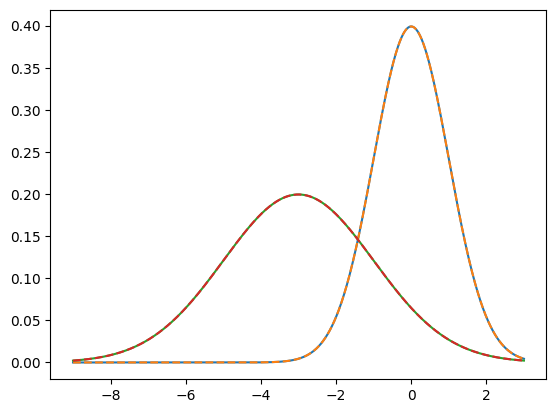

In [61]:
def phi(x, mu=0.0, sigma=1.0):
    return 1 / (np.sqrt(2 * np.pi) * sigma) * np.exp(-0.5 * (x - mu) ** 2 / sigma**2)


grid = np.linspace(-9, 3, 1000)
plt.plot(grid, stats.norm().pdf(grid))
plt.plot(grid, phi(grid), "--")

mu = -3
sigma = 2
plt.plot(grid, stats.norm(loc=mu, scale=sigma).pdf(grid))
plt.plot(grid, phi(grid, mu=mu, sigma=sigma), "--")
plt.show()

#### Truncated normal distributions and their densities

The truncated normal distribution with parameters $a$, $b$, $\mu$, and $\sigma$ satisfying $a < b$ is defined by its density function:
$$
\varphi(x\mid a, b, \mu, \sigma) = \frac{\mathbf{1}_{[a, b]}(x)\varphi(x\mid\mu, \sigma)}{\Phi(b\mid\mu, \sigma) - \Phi(a\mid\mu, \sigma)}\tag{$*$}
$$

A distribution `d` with density $\varphi(x\mid a, b; 0, 1)$ can be constructed as follows:
```python
d = stats.truncnorm(a, b)
```

##### Exercise 2

Plot the $\varphi(x\mid -2, 1; 0, 1)$ on the interval $[-2.5, 1.5]$ both by using formula $(*)$ directly and by constructing a distribution `d` as above and using the method `d.pdf`. When coding up formula $(*)$, use `norm().pdf` for $\varphi$ and `norm().cdf` for $\Phi$.

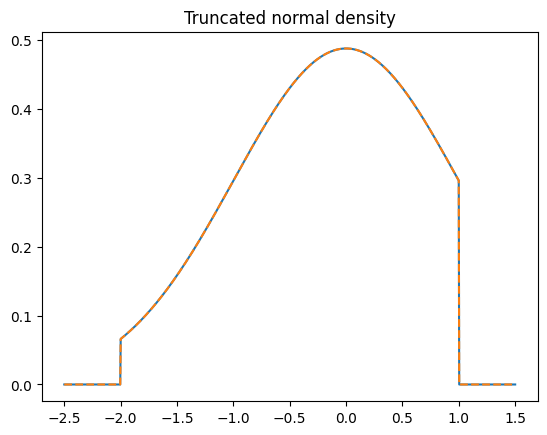

In [62]:
def phi(x, a, b):
    n = stats.norm()
    mask = np.logical_and(x >= a, x <= b)
    return mask * n.pdf(x) / (n.cdf(b) - n.cdf(a))


a = -2
b = 1
d = stats.truncnorm(a, b)
grid = np.linspace(-2.5, 1.5, 1000)
plt.plot(grid, d.pdf(grid))
plt.plot(grid, phi(grid, a, b), "--")
plt.title("Truncated normal density")
plt.show()

#### Moments of $\varphi(x\mid a, b; 0, 1)$

One can show that if $X\sim \varphi(x\mid a, b; 0, 1)$, then
$$
E[X] = \frac{\varphi(a) - \varphi(b)}{\Phi(b) - \Phi(a)} = m_1(a, b)
$$
and
$$
E[X^2] = 1 + \frac{a\varphi(a) - b\varphi(b)}{\Phi(b) - \Phi(a)} = m_2(a, b).
$$


##### Exercise 3

Verify these formulas for the distribution $\varphi(x\mid -2, 1; 0, 1)$. Use `norm().pdf` for $\varphi$, `norm().cdf` for $\Phi$, and `d.moment` to compute the moments of a distribution `d`.

In [63]:
def m_1(a, b):
    n = stats.norm()
    return (n.pdf(a) - n.pdf(b)) / (n.cdf(b) - n.cdf(a))


def m_2(a, b):
    n = stats.norm()
    return 1 + (a * n.pdf(a) - b * n.pdf(b)) / (n.cdf(b) - n.cdf(a))


a = -2
b = 1
d = stats.truncnorm(a, b)

assert np.isclose(d.moment(1), m_1(a, b))
assert np.isclose(d.moment(2), m_2(a, b))

So far, we've only considered truncations of the standard normal distribution.
Constructing truncations of general normal distributions is a bit trickier.
Here's the incantation for constructing the truncated normal distribution `d` with density $\varphi(x\mid a, b;\mu, \sigma)$:
```python
alpha = (a - mu) / sigma
beta = (b - mu) / sigma
d = stats.truncnorm(alpha, beta, loc=mu, scale=sigma)
```

##### Exercise 4

For $\varphi(0.5, 3; 1.5, 1)$, verify that `d.pdf` is, indeed, described by formula $(*)$.

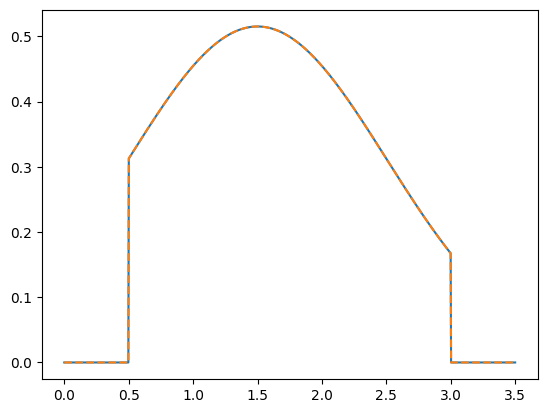

In [64]:
def phi(x, a, b, mu=0.0, sigma=1.0):
    n = stats.norm(loc=mu, scale=sigma)
    mask = np.logical_and(x >= a, x <= b)
    return mask * n.pdf(x) / (n.cdf(b) - n.cdf(a))


mu = 1.5
sigma = 1
a = 0.5
b = 3
alpha = (a - mu) / sigma
beta = (b - mu) / sigma
d = stats.truncnorm(alpha, beta, loc=mu, scale=sigma)
grid = np.linspace(0, 3.5, 1000)
plt.plot(grid, d.pdf(grid))
plt.plot(grid, phi(grid, a, b, mu=mu, sigma=sigma), "--")
plt.show()

#### Moments of $\varphi(x\mid a, b;\mu, \sigma)$

Suppose $X\sim \varphi(x\mid a, b;\mu, \sigma)$.

Set
$$
\alpha = \frac{a - \mu}{\sigma},\qquad \beta = \frac{b - \mu}{\sigma}.
$$

Then
$$
E[X] = \sigma m_1(\alpha, \beta) + \mu = M_1(a, b; \mu, \sigma)
$$
and
$$
E[X^2] = \sigma^2 m_2(\alpha, \beta) + 2\mu\sigma m_1(\alpha, \beta) + \mu^2 = M_2(a, b;\mu, \sigma).
$$

##### Exercise 5

Verify these formulas for $\varphi(0.5, 3; 1.5, 1)$.

In [65]:
def M_1(a, b, mu=0.0, sigma=1.0):
    alpha = (a - mu) / sigma
    beta = (b - mu) / sigma
    return mu + sigma * m_1(alpha, beta)


def M_2(a, b, mu=0.0, sigma=1.0):
    alpha = (a - mu) / sigma
    beta = (b - mu) / sigma
    return sigma**2 * m_2(alpha, beta) + 2 * mu * sigma * m_1(alpha, beta) + mu**2


mu = 1.5
sigma = 1
a = 0.5
b = 3
alpha = (a - mu) / sigma
beta = (b - mu) / sigma
d = stats.truncnorm(alpha, beta, loc=mu, scale=sigma)
assert np.isclose(d.mean(), M_1(a, b, mu=mu, sigma=sigma))
assert np.isclose(d.moment(2), M_2(a, b, mu=mu, sigma=sigma))

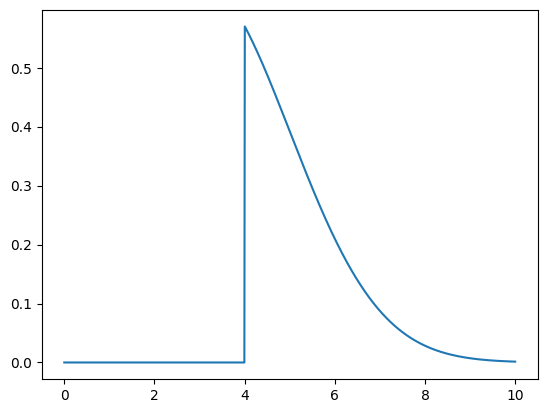

In [66]:
def psi(x):
    n = stats.norm()
    return n.pdf(x) / (1 - n.cdf(x))


def first_moment(mu, sigma, a):
    alpha = (a - mu) / sigma
    return mu + sigma * psi(alpha)


def second_moment(mu, sigma, a):
    alpha = (a - mu) / sigma
    return mu**2 + sigma**2 + sigma * psi(alpha) * (2 * mu + sigma * alpha)


mu = 3
sigma = 2
a = 4
b = np.inf
alpha = (a - mu) / sigma
beta = (b - mu) / sigma
d = stats.truncnorm(alpha, beta, loc=mu, scale=sigma)

assert np.isclose(d.moment(1), first_moment(mu, sigma, a))
assert np.isclose(d.moment(2), second_moment(mu, sigma, a))

grid = np.linspace(0, 10, 1000)
plt.plot(grid, d.pdf(grid))
plt.show()

### Maximum likelihood estimation (known variance)

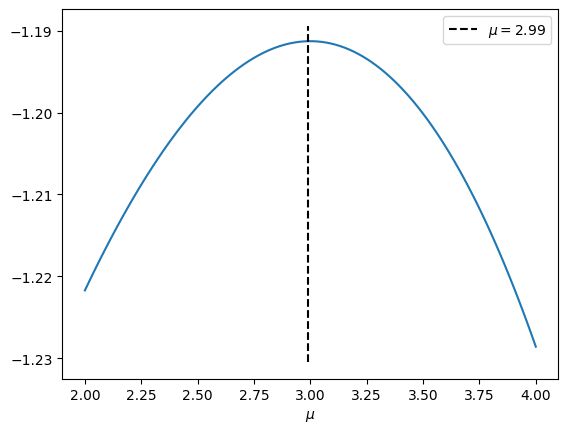

In [76]:
x = d.rvs(size=(1, 200))
mus = np.linspace(2, 4, 100).reshape(-1, 1)
alphas = (a - mus) / sigma
betas = (b - mus) / sigma
log_likelihood = (
    stats.truncnorm(alphas, betas, loc=mus, scale=sigma).logpdf(x).mean(axis=1)
)
plt.plot(mus, log_likelihood)
plt.xlabel("$\\mu$")
mumax = mus[log_likelihood.argmax()].item()
ymin, ymax = plt.ylim()
plt.plot([mumax, mumax], [ymin, ymax], "--k", label=f"$\\mu = {mumax:.2f}$")
plt.legend()
plt.show()

In [ ]:
mus = np.linspace(2, 4, 100)
sigmas = np.linspace(1, 3, 200)
MUS, SIGMAS = np.meshgrid(mus, sigmas)
MUS = MUS[:, :, None]
SIGMAS = SIGMAS[:, :, None]
alphas = (a - MUS) / SIGMAS
betas = (b - MUS) / SIGMAS
x = d.rvs(size=(1, 1, 300))
log_likelihood = (
    stats.truncnorm(alphas, betas, loc=MUS, scale=SIGMAS).logpdf(x).mean(axis=-1)
)

In [105]:
i = log_likelihood.max(axis=1).argmax()
j = log_likelihood.max(axis=0).argmax()

In [106]:
log_likelihood[i, j]

np.float64(-1.2605693551088428)

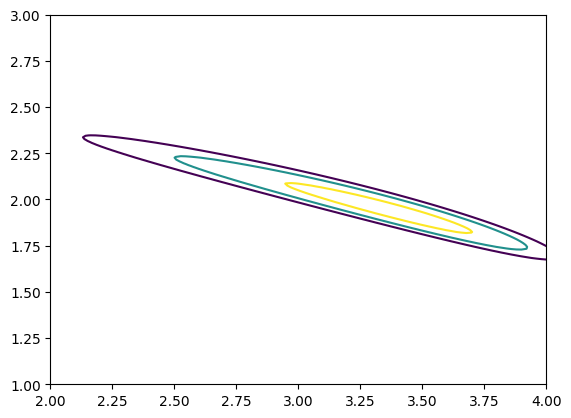

In [ ]:
plt.contour(
    MUS.squeeze(), SIGMAS.squeeze(), log_likelihood, levels=[-1.263, -1.262, -1.261]
)